# EDA: Provided Data + Climate/Fuel Features

Explores the provided portfolio/claims data and the derived FWI/fuel features. Region config: `src/common.py`.

Data dictionary: [`../docs/data_dictionary.md`](../docs/data_dictionary.md)

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from common import REGION_NAME, FWI_COMPONENT_AGG_COLUMNS, FWI_FEATURE_COLUMNS

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_RAW = "../data/raw"
DATA_PROCESSED = "../data/processed"

OUTPUT_FIGURES = Path("../outputs/figures")
OUTPUT_MAPS = Path("../outputs/maps")
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_MAPS.mkdir(parents=True, exist_ok=True)


def savefig(fig, out_dir: Path, name: str):
    path = out_dir / f"{REGION_NAME}_{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved {path}")


print(f"Region: {REGION_NAME}")


Region: alberta


## 1. Load the raw provided data

`provided_portfolio_data.csv` (current exposure, one row per FSA) and `provided_claims_data.csv` (historical losses, one row per FSA/event).

In [2]:
portfolio = pd.read_csv(f"{DATA_RAW}/provided_portfolio_data.csv")
claims = pd.read_csv(f"{DATA_RAW}/provided_claims_data.csv")

print("portfolio:", portfolio.shape)
print("claims:", claims.shape)
portfolio.head()


portfolio: (159, 3)
claims: (305, 6)


,FSA,Number of Exposure,$ Average Exposure
0,T0A,28400,76356.646481
1,T0B,31600,81099.028317
2,T0C,31000,80253.432729
3,T0E,21800,73116.864282
4,T0G,16500,69564.648787


In [3]:
claims.head()


,FSA,Loss Dates,Number of Exposure,$ Average Exposure,Loss Frequency,Total $ Loss
0,T0A,"May 3 - May 18, 2016",23300,69124.675963,0.01159,87986.226355
1,T0B,"May 3 - May 18, 2016",25900,73417.892374,0.00270,8260.251107
2,T0C,"May 3 - May 18, 2016",25400,72652.385719,0.00432,69261.650819
3,T0E,"May 3 - May 18, 2016",17900,66191.743403,0.00224,3501.242348
4,T0G,"May 3 - May 18, 2016",13500,62975.969055,0.00666,74490.970643


## 2. Portfolio (current exposure) -- structure and quality

In [4]:
portfolio.info()


<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FSA                 159 non-null    str    
 1   Number of Exposure  159 non-null    int64  
 2   $ Average Exposure  159 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 4.3 KB


In [5]:
print("Duplicate FSAs in portfolio:", portfolio["FSA"].duplicated().sum())
print("Missing values:\n", portfolio.isna().sum())
portfolio.describe()


Duplicate FSAs in portfolio: 0
Missing values:
 FSA                   0
Number of Exposure    0
$ Average Exposure    0
dtype: int64


,Number of Exposure,$ Average Exposure
count,159.000000,159.000000
mean,12394.339623,83018.706712
std,9273.251620,19590.297821
min,100.000000,32508.248349
25%,5550.000000,73262.536960
50%,10300.000000,80476.918863
75%,18000.000000,89638.403078
max,49300.000000,188267.527280


Saved ../outputs/figures/alberta_portfolio_exposure_distributions.png


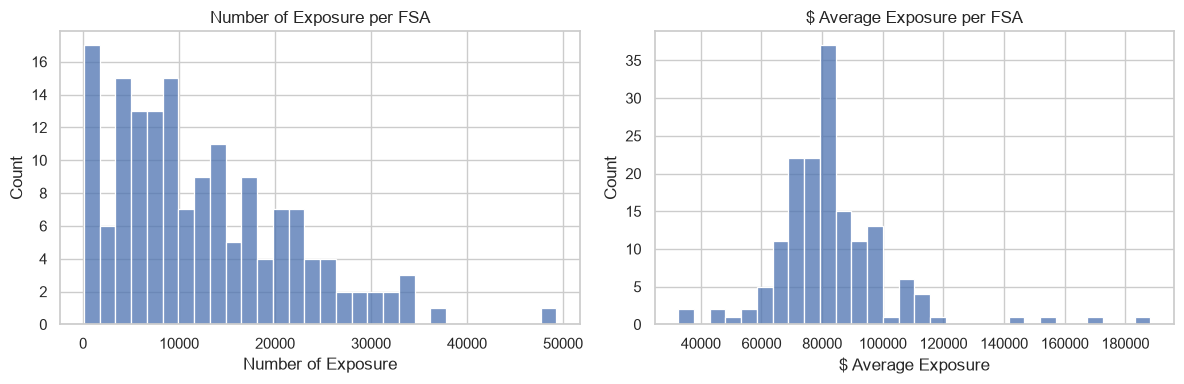

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(portfolio["Number of Exposure"], bins=30, ax=axes[0])
axes[0].set_title("Number of Exposure per FSA")
sns.histplot(portfolio["$ Average Exposure"], bins=30, ax=axes[1])
axes[1].set_title("$ Average Exposure per FSA")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "portfolio_exposure_distributions")
plt.show()


159 FSAs, no duplicates, no missing values. Both columns right-skewed.

## 3. Claims (historical losses) -- structure and quality

In [7]:
claims.info()


<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FSA                 305 non-null    str    
 1   Loss Dates          305 non-null    str    
 2   Number of Exposure  305 non-null    int64  
 3   $ Average Exposure  305 non-null    float64
 4   Loss Frequency      305 non-null    float64
 5   Total $ Loss        305 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 22.0 KB


In [8]:
print("Missing values:\n", claims.isna().sum())
print()
print("Distinct events (Loss Dates):")
print(claims["Loss Dates"].value_counts())


Missing values:
 FSA                   0
Loss Dates            0
Number of Exposure    0
$ Average Exposure    0
Loss Frequency        0
Total $ Loss          0
dtype: int64

Distinct events (Loss Dates):
Loss Dates
July 22 - August 17, 2024    153
May 3 - May 18, 2016         152
Name: count, dtype: int64


Only 2 distinct historical loss events in this sample.

In [9]:
event_summary = claims.groupby("Loss Dates").agg(
    n_fsa_rows=("FSA", "count"),
    n_fsa_with_loss=("Total $ Loss", lambda s: (s > 0).sum()),
    total_loss=("Total $ Loss", "sum"),
    mean_loss_frequency=("Loss Frequency", "mean"),
)
event_summary


,n_fsa_rows,n_fsa_with_loss,total_loss,mean_loss_frequency
Loss Dates,,,,
"July 22 - August 17, 2024",153,21,2.374869e+07,0.003489
"May 3 - May 18, 2016",152,101,8.437093e+07,0.025620


Saved ../outputs/figures/alberta_claims_loss_distributions.png


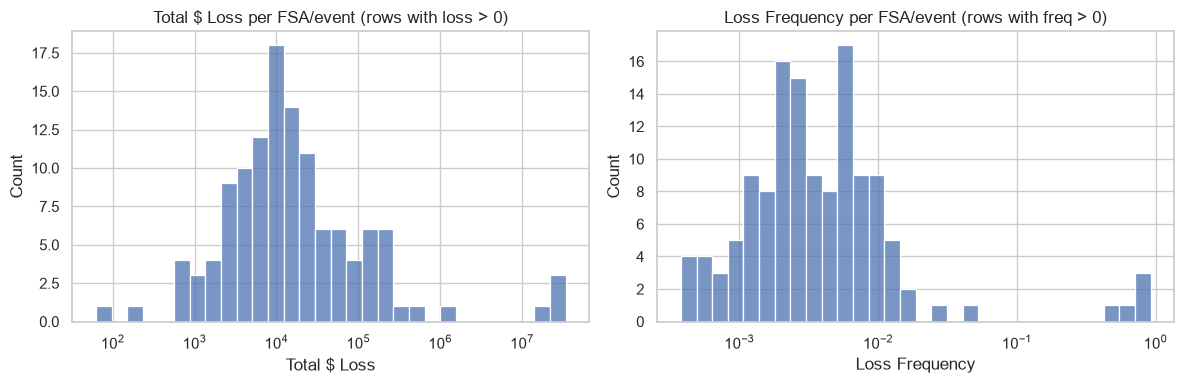

Rows with zero Total $ Loss: 183 / 305

Largest 4 losses:
FSA                Loss Dates  Total $ Loss  Loss Frequency
T9H      May 3 - May 18, 2016  3.394173e+07         0.82537
T9K      May 3 - May 18, 2016  2.870214e+07         0.92000
T0E July 22 - August 17, 2024  2.341079e+07         0.50000
T9J      May 3 - May 18, 2016  1.623188e+07         0.90000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(claims.loc[claims["Total $ Loss"] > 0, "Total $ Loss"], bins=30, ax=axes[0], log_scale=(True, False))
axes[0].set_title("Total $ Loss per FSA/event (rows with loss > 0)")
sns.histplot(claims.loc[claims["Loss Frequency"] > 0, "Loss Frequency"], bins=30, ax=axes[1], log_scale=(True, False))
axes[1].set_title("Loss Frequency per FSA/event (rows with freq > 0)")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "claims_loss_distributions")
plt.show()

print(f"Rows with zero Total $ Loss: {(claims['Total $ Loss'] == 0).sum()} / {len(claims)}")

top_losses = claims.nlargest(4, "Total $ Loss")
print("\nLargest 4 losses:")
print(top_losses[["FSA", "Loss Dates", "Total $ Loss", "Loss Frequency"]].to_string(index=False))


Most FSA/event rows have zero loss. `Total $ Loss` spans ~6 orders of magnitude ($62-$33.9M), hence log-x. Top losses checked against exposure - financially plausible, not data errors.

## 4. Portfolio <-> claims coverage check

In [11]:
portfolio_fsas = set(portfolio["FSA"])
claims_fsas = set(claims["FSA"])

print("FSAs in portfolio but never in claims (either event):", len(portfolio_fsas - claims_fsas))
print("FSAs in claims but not in portfolio:", len(claims_fsas - portfolio_fsas))
print("FSAs in both:", len(portfolio_fsas & claims_fsas))
print()

for event, grp in claims.groupby("Loss Dates"):
    event_fsas = set(grp["FSA"])
    missing = sorted(portfolio_fsas - event_fsas)
    print(f"{event}: {len(event_fsas)}/159 portfolio FSAs present, {len(missing)} missing entirely: {missing}")


FSAs in portfolio but never in claims (either event): 5
FSAs in claims but not in portfolio: 0
FSAs in both: 154

July 22 - August 17, 2024: 153/159 portfolio FSAs present, 6 missing entirely: ['T0N', 'T0T', 'T0V', 'T4K', 'T6N', 'T6S']
May 3 - May 18, 2016: 152/159 portfolio FSAs present, 7 missing entirely: ['T0N', 'T0T', 'T0V', 'T3T', 'T4K', 'T6S', 'T6Y']


No claims FSA falls outside the portfolio, but neither event has full 159-FSA coverage - some FSAs are missing rows entirely (not zero-loss, just absent) from one or both events.

## 5. Severity vs. exposure

Saved ../outputs/figures/alberta_severity_vs_exposure.png


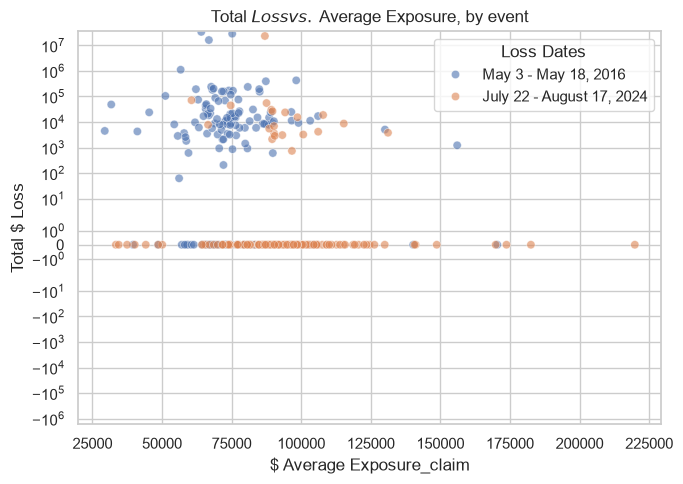

loss_ratio                                          \
                               count      mean       std  min  25%       50%   
Loss Dates                                                                     
July 22 - August 17, 2024      153.0  0.000099  0.001196  0.0  0.0  0.000000   
May 3 - May 18, 2016           152.0  0.001976  0.016940  0.0  0.0  0.000006   

                                               
                                75%       max  
Loss Dates                                     
July 22 - August 17, 2024  0.000000  0.014793  
May 3 - May 18, 2016       0.000025  0.202383

In [12]:
merged = claims.merge(portfolio, on="FSA", suffixes=("_claim", "_portfolio"))

# Normalize loss by exposure to get a rough per-event loss ratio
merged["loss_ratio"] = merged["Total $ Loss"] / (merged["Number of Exposure_claim"] * merged["$ Average Exposure_claim"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=merged, x="$ Average Exposure_claim", y="Total $ Loss",
    hue="Loss Dates", alpha=0.6, ax=ax,
)
ax.set_yscale("symlog")
ax.set_title("Total $ Loss vs. $ Average Exposure, by event")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "severity_vs_exposure")
plt.show()

merged[["Loss Dates", "loss_ratio"]].groupby("Loss Dates").describe()


No obvious linear relationship between exposure value and total loss - loss looks driven more by whether an FSA was hit than by exposure scaling.

## 6. Which FSAs were hit hardest, per event

In [13]:
for event, grp in claims.groupby("Loss Dates"):
    print(f"=== {event} ===")
    print(grp.nlargest(10, "Total $ Loss")[["FSA", "Total $ Loss", "Loss Frequency", "Number of Exposure"]].to_string(index=False))
    print()


=== July 22 - August 17, 2024 ===
FSA  Total $ Loss  Loss Frequency  Number of Exposure
T0E  2.341079e+07         0.50000               18200
T6E  7.133302e+04         0.00084               11800
T0J  5.515721e+04         0.00053               19000
T2B  4.464256e+04         0.00113                8900
T0K  3.013099e+04         0.00207               19400
T5N  2.640710e+04         0.00997                8000
T6T  2.375544e+04         0.00176               17000
T2S  1.878933e+04         0.00108                9200
T4B  1.532146e+04         0.00040               25000
T4C  8.664785e+03         0.00169               17700

=== May 3 - May 18, 2016 ===
FSA  Total $ Loss  Loss Frequency  Number of Exposure
T9H  3.394173e+07        0.825370               14300
T9K  2.870214e+07        0.920000               16700
T9J  1.623188e+07        0.900000                1200
T0P  1.114388e+06        0.678445                 600
T6R  4.275475e+05        0.004970               18100
T0L  3.944911e+05 

## 7. Climate/fuel features

Loading the pre-built claims feature table (event-window FWI + static FSA features).

In [14]:
claims_features = pd.read_csv(f"{DATA_PROCESSED}/features/{REGION_NAME}_claims_features.csv")
print(claims_features.shape)
claims_features[[
    "FSA", "Loss Dates", "Total $ Loss", "Loss Frequency",
    "climate_days_available", "window_coverage_fraction",
    "fwi_mean", "fwi_max", "dominant_fuel_code",
]].head()


(305, 25)


,FSA,Loss Dates,Total $ Loss,Loss Frequency,climate_days_available,window_coverage_fraction,fwi_mean,fwi_max,dominant_fuel_code
0,T0A,"May 3 - May 18, 2016",87986.226355,0.01159,14,0.8750,0.639919,2.949010,11.0
1,T0B,"May 3 - May 18, 2016",8260.251107,0.00270,12,0.7500,1.228688,2.669016,31.0
2,T0C,"May 3 - May 18, 2016",69261.650819,0.00432,14,0.8750,0.169061,0.740432,31.0
3,T0E,"May 3 - May 18, 2016",3501.242348,0.00224,14,0.8750,0.187088,0.682463,101.0
4,T0G,"May 3 - May 18, 2016",74490.970643,0.00666,15,0.9375,0.527373,1.985369,2.0


In [15]:
zero_cov = (claims_features["climate_days_available"] == 0).sum()
print(f"Rows with ZERO valid climate days: {zero_cov} / {len(claims_features)} ({zero_cov/len(claims_features):.0%})")
print()
print(claims_features.groupby("Loss Dates")["window_coverage_fraction"].describe())


Rows with ZERO valid climate days: 73 / 305 (24%)

                           count      mean       std  min  25%   50%    75%  \
Loss Dates                                                                    
July 22 - August 17, 2024  153.0  0.993464  0.080845  0.0  1.0  1.00  1.000   
May 3 - May 18, 2016       152.0  0.431743  0.413788  0.0  0.0  0.75  0.875   

                              max  
Loss Dates                         
July 22 - August 17, 2024  1.0000  
May 3 - May 18, 2016       0.9375  


73/305 rows (24%) have zero FWI signal (see `docs/data_dictionary.md`). Excluded from analysis below rather than treated as FWI=0.

## 8. Loss vs. FWI -- the actual hazard-driver question

Saved ../outputs/figures/alberta_fwi_vs_loss.png


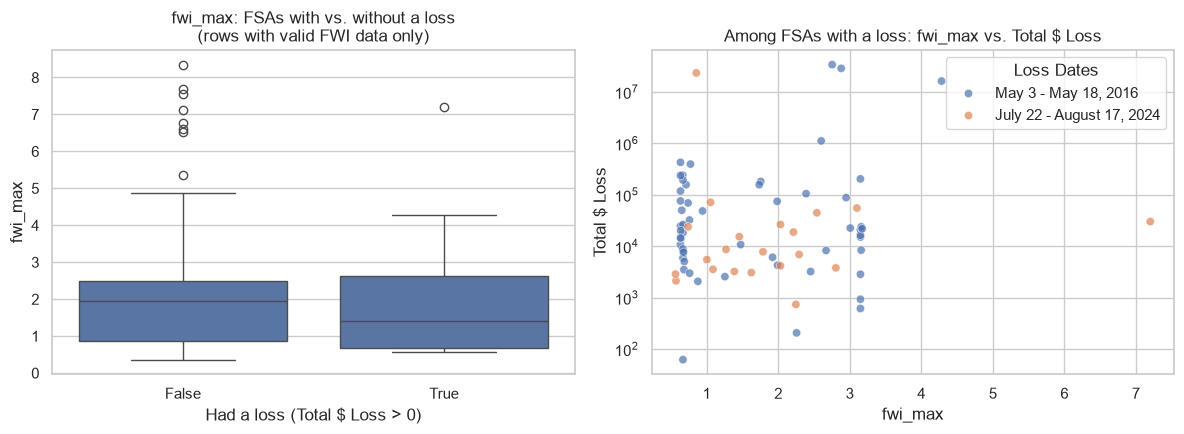

In [16]:
has_fwi = claims_features[claims_features["climate_days_available"] > 0].copy()
has_fwi["had_loss"] = has_fwi["Total $ Loss"] > 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=has_fwi, x="had_loss", y="fwi_max", ax=axes[0])
axes[0].set_title("fwi_max: FSAs with vs. without a loss\n(rows with valid FWI data only)")
axes[0].set_xlabel("Had a loss (Total $ Loss > 0)")

sns.scatterplot(
    data=has_fwi[has_fwi["Total $ Loss"] > 0],
    x="fwi_max", y="Total $ Loss", hue="Loss Dates", alpha=0.7, ax=axes[1],
)
axes[1].set_yscale("log")
axes[1].set_title("Among FSAs with a loss: fwi_max vs. Total $ Loss")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "fwi_vs_loss")
plt.show()


Saved ../outputs/figures/alberta_fwi_loss_correlation_matrix.png


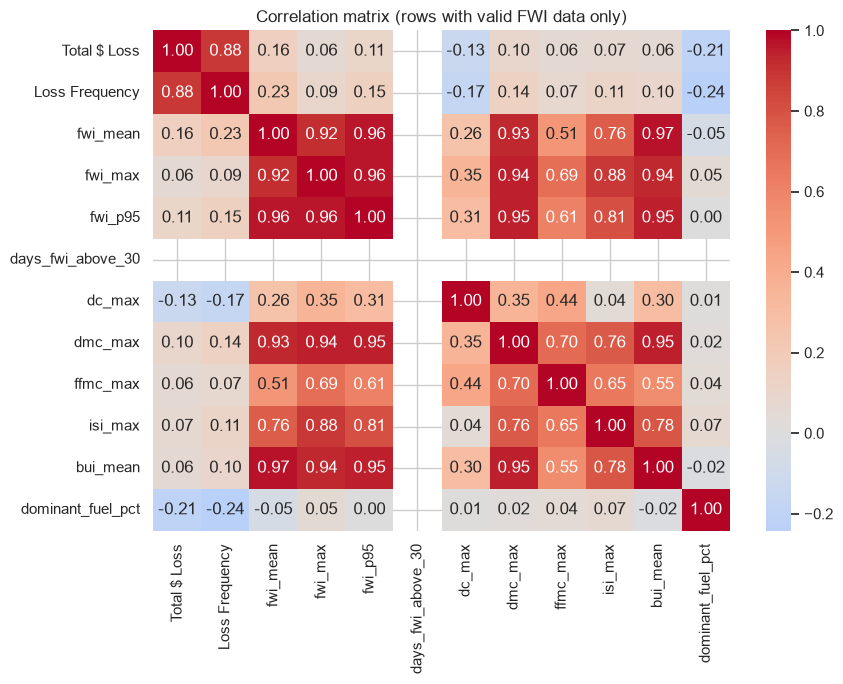

In [17]:
cols = ["Total $ Loss", "Loss Frequency"] + FWI_FEATURE_COLUMNS + ["dominant_fuel_pct"]
corr = has_fwi[cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (rows with valid FWI data only)")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "fwi_loss_correlation_matrix")
plt.show()


With only 2 events, correlations here are exploratory signal, not a basis for a final model. `days_fwi_above_30` is blank throughout: FWI never exceeded 30 in either event window in this sample (zero variance, undefined correlation) -- not usable as a model feature as-is.

## 9. Spatial pattern -- do high-loss FSAs cluster geographically?

Saved ../outputs/maps/alberta_loss_by_fsa_choropleth.png


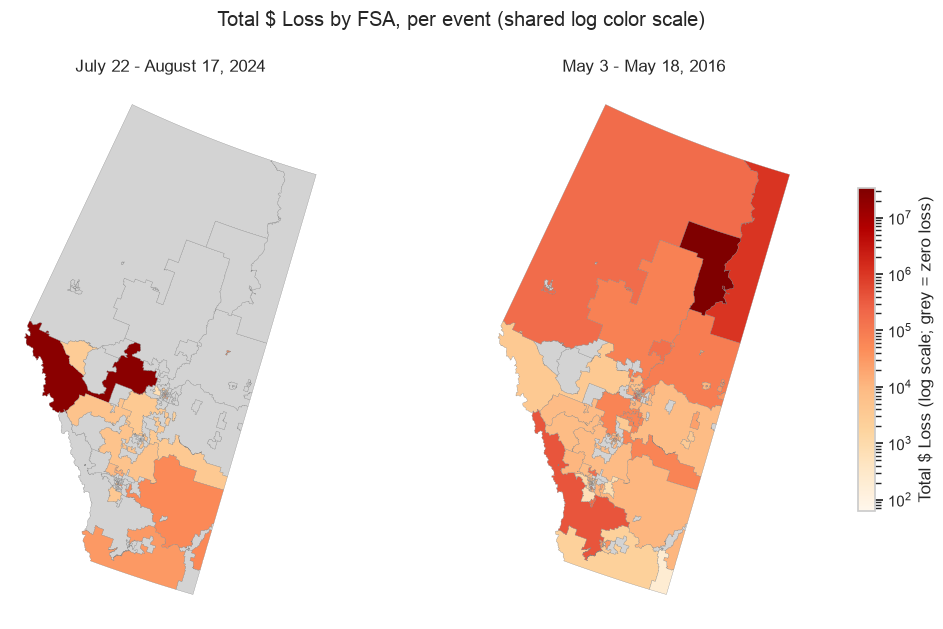

In [18]:
import geopandas as gpd
from matplotlib.colors import LogNorm

boundaries = gpd.read_file(f"{DATA_PROCESSED}/boundaries/{REGION_NAME}_fsa_boundaries.gpkg")
boundaries = boundaries.rename(columns={"CFSAUID": "FSA"})

# Log color scale (grey = zero loss, LogNorm can't represent 0); one shared
# scale across both maps so the events are directly comparable.
vmin = claims.loc[claims["Total $ Loss"] > 0, "Total $ Loss"].min()
vmax = claims["Total $ Loss"].max()
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (event, grp) in zip(axes, claims.groupby("Loss Dates")):
    plot_df = boundaries.merge(grp[["FSA", "Total $ Loss"]], on="FSA", how="left")
    plot_df["Total $ Loss"] = plot_df["Total $ Loss"].fillna(0)

    plot_df[plot_df["Total $ Loss"] == 0].plot(ax=ax, color="lightgrey", edgecolor="grey", linewidth=0.2)
    nonzero = plot_df[plot_df["Total $ Loss"] > 0]
    nonzero.plot(column="Total $ Loss", cmap="OrRd", norm=norm, ax=ax, edgecolor="grey", linewidth=0.2)
    ax.set_title(event)
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap="OrRd", norm=norm)
sm._A = []
fig.colorbar(sm, ax=axes, shrink=0.6, label="Total $ Loss (log scale; grey = zero loss)")
plt.suptitle("Total $ Loss by FSA, per event (shared log color scale)")
savefig(fig, OUTPUT_MAPS, "loss_by_fsa_choropleth")
plt.show()


In [19]:
from itertools import combinations

for event, grp in claims.groupby("Loss Dates"):
    top_fsas = set(grp.nlargest(8, "Total $ Loss")["FSA"])
    top_geo = boundaries[boundaries["FSA"].isin(top_fsas)]
    pairs = list(combinations(zip(top_geo["FSA"], top_geo.geometry), 2))
    adjacent = [(a[0], b[0]) for a, b in pairs if a[1].touches(b[1])]
    print(f"{event}: top-8 loss FSAs {sorted(top_fsas)}")
    print(f"  adjacent pairs: {len(adjacent)} / {len(pairs)} -- {adjacent}\n")


July 22 - August 17, 2024: top-8 loss FSAs ['T0E', 'T0J', 'T0K', 'T2B', 'T2S', 'T5N', 'T6E', 'T6T']
  adjacent pairs: 1 / 28 -- [('T0J', 'T0K')]

May 3 - May 18, 2016: top-8 loss FSAs ['T0L', 'T0P', 'T5T', 'T6R', 'T6W', 'T9H', 'T9J', 'T9K']
  adjacent pairs: 4 / 28 -- [('T0P', 'T9H'), ('T6R', 'T6W'), ('T9H', 'T9J'), ('T9H', 'T9K')]



July/Aug 2024 losses are localized (compact cluster); May 2016 losses are broader with one intense hotspot - consistent with the adjacency check above.

## 10. Feature distributions

Saved ../outputs/figures/alberta_fwi_distribution.png


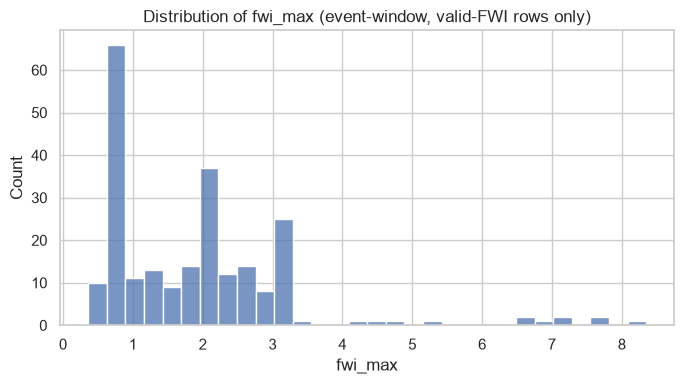

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(has_fwi["fwi_max"].dropna(), bins=30, ax=ax)
ax.set_title("Distribution of fwi_max (event-window, valid-FWI rows only)")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "fwi_distribution")
plt.show()


Saved ../outputs/figures/alberta_fwi_component_distributions.png


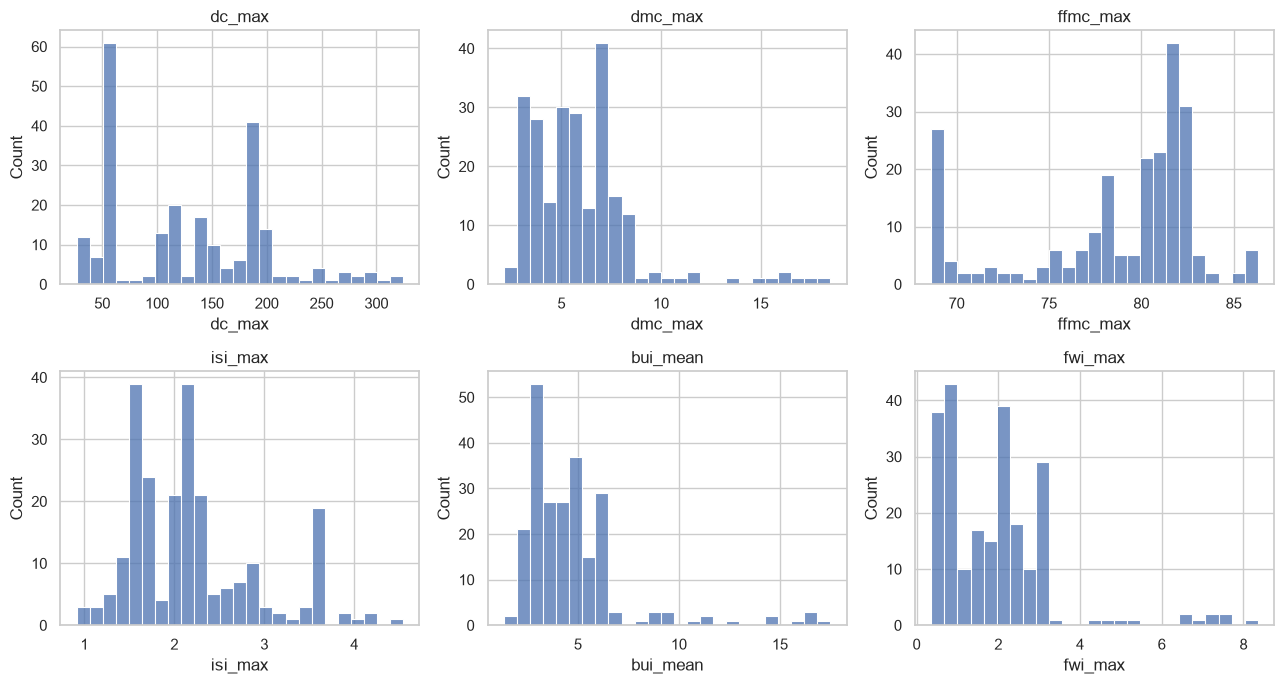

In [21]:
fwi_components = FWI_COMPONENT_AGG_COLUMNS + ["fwi_max"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, fwi_components):
    sns.histplot(has_fwi[col].dropna(), bins=25, ax=ax)
    ax.set_title(col)
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "fwi_component_distributions")
plt.show()


Saved ../outputs/figures/alberta_fuel_code_frequencies.png


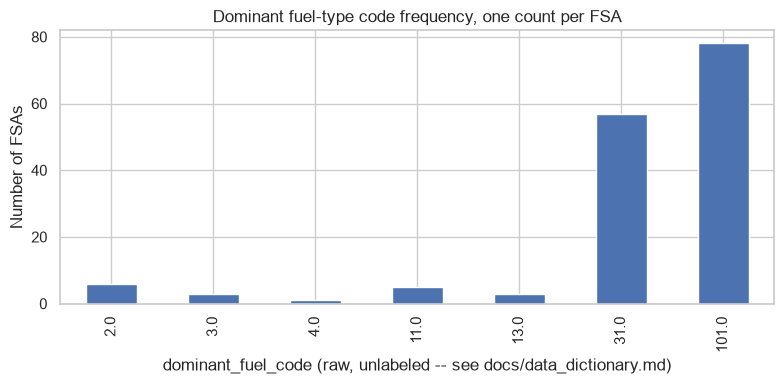

In [22]:
fuel_counts = claims_features.drop_duplicates("FSA")["dominant_fuel_code"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
fuel_counts.plot(kind="bar", ax=ax)
ax.set_xlabel("dominant_fuel_code (raw, unlabeled -- see docs/data_dictionary.md)")
ax.set_ylabel("Number of FSAs")
ax.set_title("Dominant fuel-type code frequency, one count per FSA")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "fuel_code_frequencies")
plt.show()


Saved ../outputs/figures/alberta_total_insured_value_distribution.png


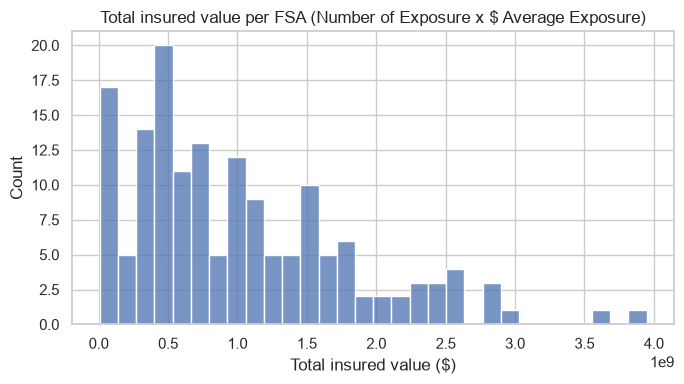

In [23]:
total_insured_value = portfolio["Number of Exposure"] * portfolio["$ Average Exposure"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(total_insured_value, bins=30, ax=ax)
ax.set_title("Total insured value per FSA (Number of Exposure x $ Average Exposure)")
ax.set_xlabel("Total insured value ($)")
plt.tight_layout()
savefig(fig, OUTPUT_FIGURES, "total_insured_value_distribution")
plt.show()


## 11. Summary

- Portfolio: 159 FSAs, clean. Claims: 305 rows, 2 events only.
- Losses concentrated in a minority of FSAs per event; largest losses checked and plausible.
- FWI/fuel features joined, with known caveats (see `docs/data_dictionary.md`): 24% zero-FWI rows, 2 FSAs with no boundary data, unlabeled fuel codes, partial portfolio/claims coverage.
- Open questions for modeling: how to handle zero-FWI rows, defensible model complexity given only 2 events, whether spatial dependence should vary by event type.